
# IMDB Sentiment Analysis — Exploratory Data Analysis (EDA)

This notebook focuses on **understanding the IMDB dataset** using TensorFlow's built‑in dataset.

We will:

1. Load the dataset using TensorFlow
2. Understand how reviews are encoded
3. Decode reviews back into readable text
4. Explore dataset size
5. Analyze review length distribution

The **model training and preprocessing pipeline are implemented in a separate Python script** so the training process can run independently.


## 1. Import Libraries

In [1]:

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


I0000 00:00:1773040824.773500  179592 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773040824.807698  179592 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773040825.652735  179592 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



## 2. Load IMDB Dataset using TensorFlow

TensorFlow provides a built‑in IMDB dataset where:

- Reviews are already converted to integer tokens
- Each number represents a word index
- Labels are:
  - `0` → negative review
  - `1` → positive review


In [2]:

vocab_size = 10000

(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))


Training samples: 25000
Test samples: 25000



## 3. Understanding Encoded Reviews

Each review is stored as a **list of integers** representing word indices.


In [3]:

print(train_data[0][:20])


[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]



## 4. Decode Reviews Back to Text

TensorFlow provides a word index dictionary that maps words to numbers.
We reverse this mapping to reconstruct readable reviews.


In [14]:
word_index = tf.keras.datasets.imdb.get_word_index()
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [ ]:
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index

{34704: 'fawn',
 52009: 'tsukino',
 52010: 'nunnery',
 16819: 'sonja',
 63954: 'vani',
 1411: 'woods',
 16118: 'spiders',
 2348: 'hanging',
 2292: 'woody',
 52011: 'trawling',
 52012: "hold's",
 11310: 'comically',
 40833: 'localized',
 30571: 'disobeying',
 52013: "'royale",
 40834: "harpo's",
 52014: 'canet',
 19316: 'aileen',
 52015: 'acurately',
 52016: "diplomat's",
 25245: 'rickman',
 6749: 'arranged',
 52017: 'rumbustious',
 52018: 'familiarness',
 52019: "spider'",
 68807: 'hahahah',
 52020: "wood'",
 40836: 'transvestism',
 34705: "hangin'",
 2341: 'bringing',
 40837: 'seamier',
 34706: 'wooded',
 52021: 'bravora',
 16820: 'grueling',
 1639: 'wooden',
 16821: 'wednesday',
 52022: "'prix",
 34707: 'altagracia',
 52023: 'circuitry',
 11588: 'crotch',
 57769: 'busybody',
 52024: "tart'n'tangy",
 14132: 'burgade',
 52026: 'thrace',
 11041: "tom's",
 52028: 'snuggles',
 29117: 'francesco',
 52030: 'complainers',
 52128: 'templarios',
 40838: '272',
 52031: '273',
 52133: 'zaniacs',

In [21]:
reverse_word_index.get(52393)

'sequals'

In [25]:
for i in range(20):
    print(reverse_word_index.get(i))

None
None
None
None
the
and
a
of
to
is
br
in
it
i
this
that
was
as
for
with


In [ ]:



reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])

print(decode_review(train_data[0]))


<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wha


## 5. Review Length Distribution

Understanding review length helps decide **padding size** for the model.


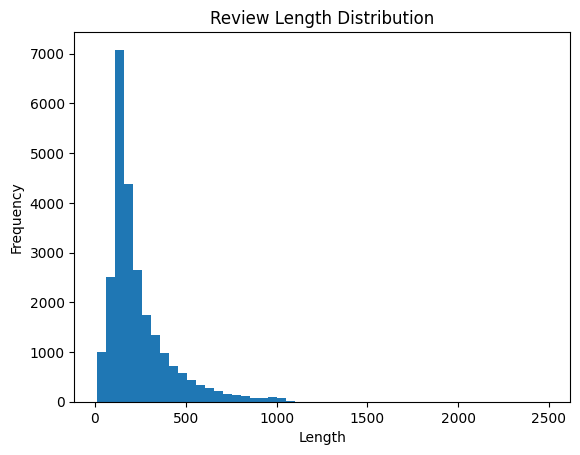

In [5]:

review_lengths = [len(x) for x in train_data]

plt.hist(review_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()



Most reviews fall within a certain length range, which helps us determine the **maximum sequence length** used during preprocessing in the training script.


# Model training pre processing

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -------------------------------
# 1. Load Dataset
# -------------------------------

vocab_size = 10000

(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(
    num_words=vocab_size
)

print("Training samples:", len(train_data))
print("Test samples:", len(test_data))


Training samples: 25000
Test samples: 25000


In [7]:
# -------------------------------
# 2. Preprocessing
# -------------------------------

max_length = 256

train_data = pad_sequences(
    train_data,
    value=0,
    padding="post",
    maxlen=max_length
)

test_data = pad_sequences(
    test_data,
    value=0,
    padding="post",
    maxlen=max_length
)

In [8]:
train_data

array([[   1,   14,   22, ...,    0,    0,    0],
       [   1,  194, 1153, ...,    0,    0,    0],
       [   1,   14,   47, ...,    0,    0,    0],
       ...,
       [   1,   11,    6, ...,    0,    0,    0],
       [   1, 1446, 7079, ...,    0,    0,    0],
       [   1,   17,    6, ...,    0,    0,    0]], dtype=int32)